<!-- # Copyright (c) 2025 takotime808 -->
# Multi-Fidelity Surrogates: Native vs Wrapped

This notebook contrasts two approaches to multi-fidelity modelling in `multioutreg`:

| Approach | Class | Key idea |
|---|---|---|
| **Wrapped** | `MultiFidelitySurrogate` | One independent surrogate per fidelity level; no cross-level information transfer |
| **Native MF** | `StackedVFMSurrogate` | Recursive feature augmentation — each level receives lower-level predictions as additional inputs |
| **Native MF** | `AdditiveCorrectionVFM` | Explicit additive correction: $\hat{f}_{\text{hi}}(x) = f_{\text{lo}}(x) + \delta(x)$ |

**Quick guide:**
- **Wrapped** models are a fast baseline. Each level is a standalone surrogate — fitting `"hi"` ignores `"lo"` data entirely.
- **Native MF** models explicitly transfer information across fidelities. They generally outperform wrapped models when the hi-fi dataset is small.

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from multioutreg.surrogates import (
    # Multi-fidelity
    MultiFidelitySurrogate,
    StackedVFMSurrogate,
    AdditiveCorrectionVFM,
    # Single-level wrapped surrogates used as building blocks
    RandomForestSurrogate,
    GaussianProcessSurrogate,
    LinearRegressionSurrogate,
    ExtraTreesRegressorSurrogate,
    BayesianRidgeSurrogate,
)

## 1. Synthetic Multi-Fidelity Data

We use a 2-output nonlinear function as the ground-truth high-fidelity model and a biased, smoothed version as the low-fidelity approximation:

$$f_{\text{hi}}(x) = [\sin(1.8x) + 0.15x,\; \cos(1.2x) - 0.08x^2]$$
$$f_{\text{lo}}(x) = 0.8 \cdot f_{\text{hi}}(x) + 0.35x + 0.15$$

We deliberately use **more** low-fidelity points and **fewer** high-fidelity points — the regime where multi-fidelity methods help most.

lo-fi:  X (120, 1)  Y (120, 2)
hi-fi:  X (30, 1)  Y (30, 2)


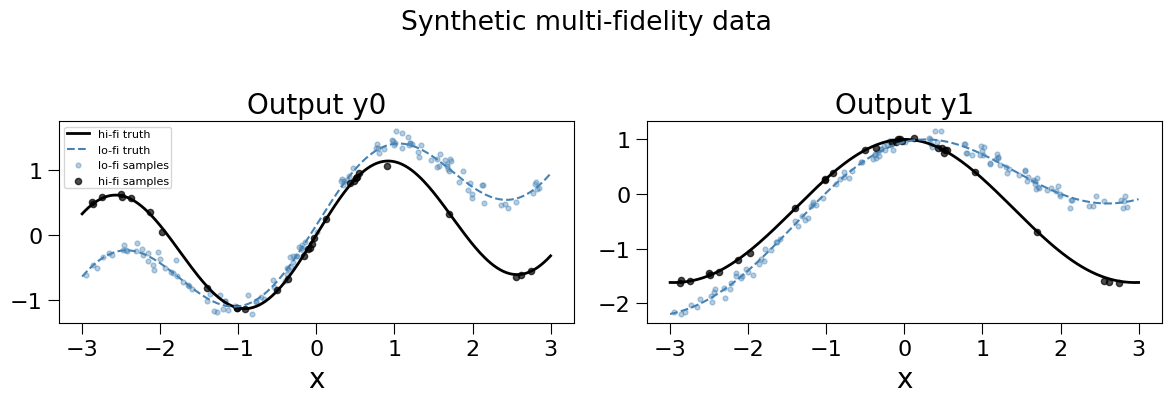

In [2]:
rng = np.random.default_rng(42)

n_lo, n_hi, n_test = 120, 30, 300

X_lo   = rng.uniform(-3.0, 3.0, size=(n_lo, 1))
X_hi   = rng.uniform(-3.0, 3.0, size=(n_hi, 1))
X_test = np.linspace(-3.0, 3.0, n_test).reshape(-1, 1)


def f_hi(x):
    y1 = np.sin(1.8 * x) + 0.15 * x
    y2 = np.cos(1.2 * x) - 0.08 * x ** 2
    return np.hstack([y1, y2])


def f_lo(x):
    return 0.8 * f_hi(x) + 0.35 * x + 0.15


Y_lo   = f_lo(X_lo) + rng.normal(scale=0.08, size=(n_lo, 2))
Y_hi   = f_hi(X_hi) + rng.normal(scale=0.03, size=(n_hi, 2))
Y_true = f_hi(X_test)

mf_data = {"lo": (X_lo, Y_lo), "hi": (X_hi, Y_hi)}

print(f"lo-fi:  X {X_lo.shape}  Y {Y_lo.shape}")
print(f"hi-fi:  X {X_hi.shape}  Y {Y_hi.shape}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)
for j, ax in enumerate(axes):
    ax.plot(X_test[:, 0], Y_true[:, j],  color="black", lw=2, label="hi-fi truth")
    ax.plot(X_test[:, 0], f_lo(X_test)[:, j], color="steelblue", lw=1.5, ls="--", label="lo-fi truth")
    ax.scatter(X_lo[:, 0], Y_lo[:, j], s=12, alpha=0.4, color="steelblue", label="lo-fi samples")
    ax.scatter(X_hi[:, 0], Y_hi[:, j], s=20, alpha=0.7, color="black",    label="hi-fi samples")
    ax.set_title(f"Output y{j}")
    ax.set_xlabel("x")
axes[0].legend(fontsize=8)
fig.suptitle("Synthetic multi-fidelity data", y=1.02)
fig.tight_layout()
plt.show()

## 2. Wrapped Surrogates — `MultiFidelitySurrogate`

`MultiFidelitySurrogate` stores one independent surrogate per fidelity level.  Fitting level `"hi"` uses **only** the hi-fi training pairs — no information from the lo-fi data is used.

Any `BaseSurrogate` subclass (RF, GP, linear, …) can be plugged in.

In [3]:
wrapped_models = {
    "Wrapped · RF": MultiFidelitySurrogate(RandomForestSurrogate, ["lo", "hi"]),
    "Wrapped · GP": MultiFidelitySurrogate(GaussianProcessSurrogate, ["lo", "hi"]),
    "Wrapped · Linear": MultiFidelitySurrogate(LinearRegressionSurrogate, ["lo", "hi"]),
}

for name, model in wrapped_models.items():
    model.fit(mf_data)
    print(f"{name}: fitted")

# Predict at the high-fidelity level
wrapped_preds = {
    name: model.predict(X_test, level="hi")
    for name, model in wrapped_models.items()
}

Wrapped · RF: fitted
Wrapped · GP: fitted
Wrapped · Linear: fitted


### Inspect predictions at each fidelity level

Because each level has its own surrogate, you can query any level independently.

RF wrapped — lo-level predictions: (300, 2)
RF wrapped — hi-level predictions: (300, 2)


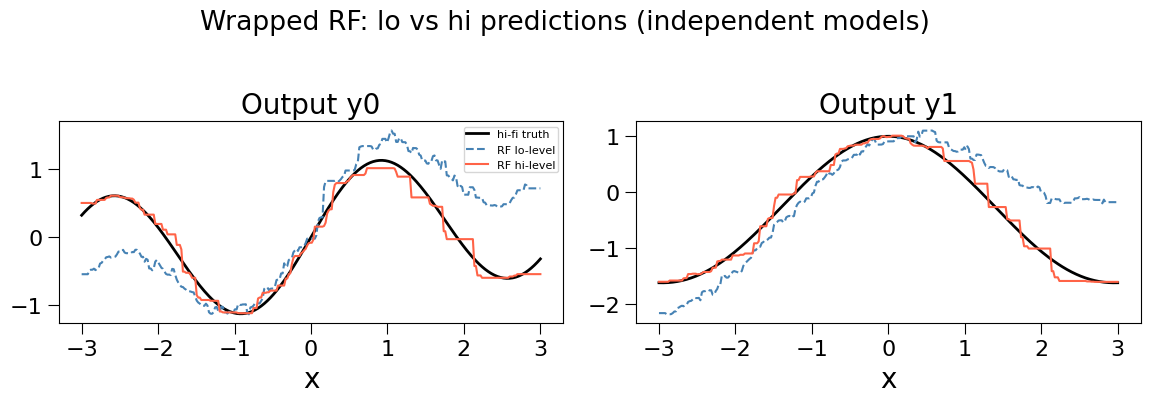

In [4]:
rf_wrapped = wrapped_models["Wrapped · RF"]

y_lo_pred = rf_wrapped.predict(X_test, level="lo")
y_hi_pred = rf_wrapped.predict(X_test, level="hi")

print("RF wrapped — lo-level predictions:", y_lo_pred.shape)
print("RF wrapped — hi-level predictions:", y_hi_pred.shape)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)
for j, ax in enumerate(axes):
    ax.plot(X_test[:, 0], Y_true[:, j],   color="black",    lw=2,   label="hi-fi truth")
    ax.plot(X_test[:, 0], y_lo_pred[:, j], color="steelblue", lw=1.5, ls="--", label="RF lo-level")
    ax.plot(X_test[:, 0], y_hi_pred[:, j], color="tomato",   lw=1.5, label="RF hi-level")
    ax.set_title(f"Output y{j}")
    ax.set_xlabel("x")
axes[0].legend(fontsize=8)
fig.suptitle("Wrapped RF: lo vs hi predictions (independent models)", y=1.02)
fig.tight_layout()
plt.show()

## 3. Native Multi-Fidelity Surrogates

### 3a. `StackedVFMSurrogate` — Recursive Feature Augmentation

At each level $k$, the input $x$ is augmented with the predictions of all lower-level surrogates before fitting.  This lets the hi-fi model learn a **nonlinear correction** over the lo-fi prediction (Perdikaris et al. 2017).

```
Level 0 (lo):  fit surrogate_0(X_lo) → Y_lo
Level 1 (hi):  X_aug = [X_hi | surrogate_0(X_hi)]
               fit surrogate_1(X_aug) → Y_hi
```

In [5]:
stacked = StackedVFMSurrogate(
    fidelity_levels=["lo", "hi"],
    surrogate_cls=[RandomForestSurrogate, GaussianProcessSurrogate],
)
stacked.fit(mf_data)

# Default predict() targets the highest level
y_stacked = stacked.predict(X_test)
print("StackedVFM hi-fi prediction shape:", y_stacked.shape)

# You can also query any intermediate level
y_stacked_lo = stacked.predict(X_test, level="lo")
print("StackedVFM lo-level prediction shape:", y_stacked_lo.shape)

StackedVFM hi-fi prediction shape: (300, 2)
StackedVFM lo-level prediction shape: (300, 2)


### 3b. `AdditiveCorrectionVFM` — AR1-Style Additive Correction

Models the hi-fi response as the sum of a lo-fi surrogate and an additive correction:

$$\hat{f}_{\text{hi}}(x) = f_{\text{lo}}(x) + \delta(x), \quad \delta = Y_{\text{hi}} - f_{\text{lo}}(X_{\text{hi}})$$

Use `lo_surrogate_cls` for the base model and `hi_surrogate_cls` for the correction model.  The correction is typically smooth, so a GP is a natural choice.

In [6]:
additive = AdditiveCorrectionVFM(
    lo_surrogate_cls=RandomForestSurrogate,
    hi_surrogate_cls=GaussianProcessSurrogate,  # fits the correction delta
)
additive.fit(mf_data)

y_additive, y_additive_std = additive.predict(X_test, return_std=True)
print("AdditiveCorrectionVFM prediction shape:", y_additive.shape)
print("AdditiveCorrectionVFM std shape:        ", y_additive_std.shape)

AdditiveCorrectionVFM prediction shape: (300, 2)
AdditiveCorrectionVFM std shape:         (300, 2)


#### Decompose prediction into components

`predict_components()` returns the lo-fi baseline and the learned correction separately, which is useful for understanding how much each part contributes.

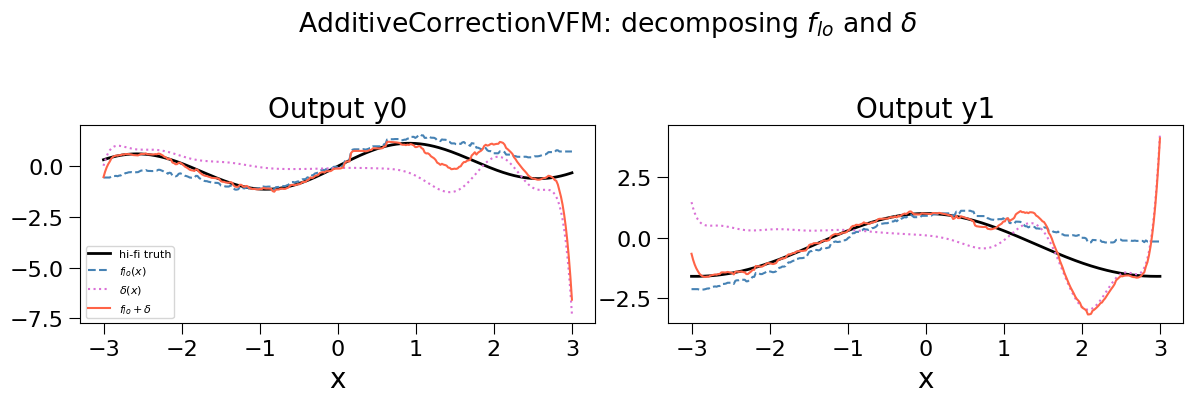

In [7]:
y_lo_component, delta_component = additive.predict_components(X_test)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)
for j, ax in enumerate(axes):
    ax.plot(X_test[:, 0], Y_true[:, j],          color="black",     lw=2,   label="hi-fi truth")
    ax.plot(X_test[:, 0], y_lo_component[:, j],   color="steelblue", lw=1.5, ls="--", label="$f_{lo}(x)$")
    ax.plot(X_test[:, 0], delta_component[:, j],  color="orchid",    lw=1.5, ls=":",  label="$\\delta(x)$")
    ax.plot(X_test[:, 0], y_additive[:, j],        color="tomato",    lw=1.5, label="$f_{lo} + \\delta$")
    ax.set_title(f"Output y{j}")
    ax.set_xlabel("x")
axes[0].legend(fontsize=8)
fig.suptitle("AdditiveCorrectionVFM: decomposing $f_{lo}$ and $\\delta$", y=1.02)
fig.tight_layout()
plt.show()

## 4. RMSE Comparison

Evaluate all models against the true hi-fi function on the test grid.

In [8]:
def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred) ** 2, axis=0))


all_preds = {
    **wrapped_preds,
    "Native · StackedVFM (RF+GP)": y_stacked,
    "Native · AdditiveCorrectionVFM (RF+GP)": y_additive,
}

rows = []
for name, y_hat in all_preds.items():
    e = rmse(Y_true, y_hat)
    rows.append(
        {"Model": name, "RMSE y0": round(float(e[0]), 4), "RMSE y1": round(float(e[1]), 4),
         "RMSE mean": round(float(np.mean(e)), 4)}
    )

df = pd.DataFrame(rows).sort_values("RMSE mean").reset_index(drop=True)
df

,Model,RMSE y0,RMSE y1,RMSE mean
0,Wrapped · RF,0.1014,0.1183,0.1099
1,Wrapped · GP,0.1159,0.4062,0.2610
2,Native · AdditiveCorrectionVFM (RF+GP),0.7200,0.8007,0.7603
3,Wrapped · Linear,0.7049,1.0356,0.8702
4,Native · StackedVFM (RF+GP),5.7603,10.4625,8.1114


## 5. Prediction Plots

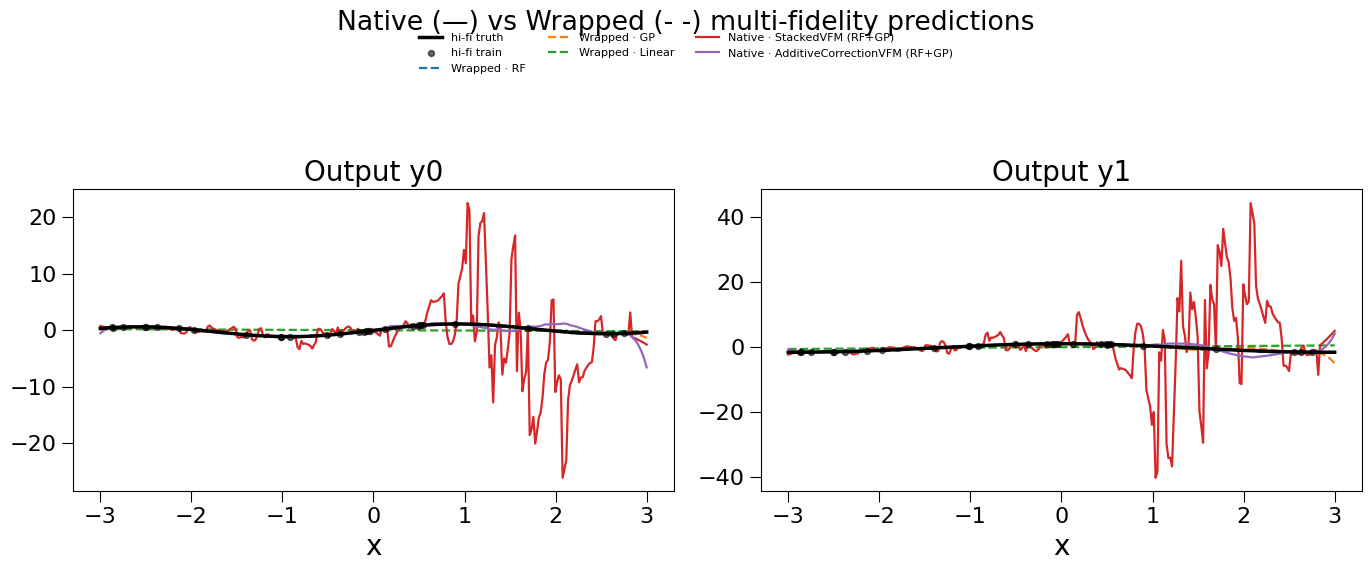

In [9]:
colors = plt.cm.tab10.colors
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)

for j, ax in enumerate(axes):
    ax.plot(X_test[:, 0], Y_true[:, j], color="black", lw=2.5, label="hi-fi truth", zorder=5)
    ax.scatter(X_hi[:, 0], Y_hi[:, j], s=18, color="black", alpha=0.6, zorder=6, label="hi-fi train")

    for i, (name, y_hat) in enumerate(all_preds.items()):
        ls = "-" if "Native" in name else "--"
        ax.plot(X_test[:, 0], y_hat[:, j], lw=1.6, ls=ls, color=colors[i], label=name)

    ax.set_title(f"Output y{j}")
    ax.set_xlabel("x")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3, fontsize=8, frameon=False,
           bbox_to_anchor=(0.5, 1.12))
fig.suptitle("Native (—) vs Wrapped (- -) multi-fidelity predictions", y=1.15)
fig.tight_layout()
plt.show()

## 6. Uncertainty Estimates

Models that support `return_std=True` provide predictive standard deviations.

- `AdditiveCorrectionVFM` combines lo-fi and delta uncertainties in quadrature.
- `GaussianProcessSurrogate` returns the GP posterior std.
- Models without native uncertainty (RF, linear) return zeros from `BaseSurrogate`.

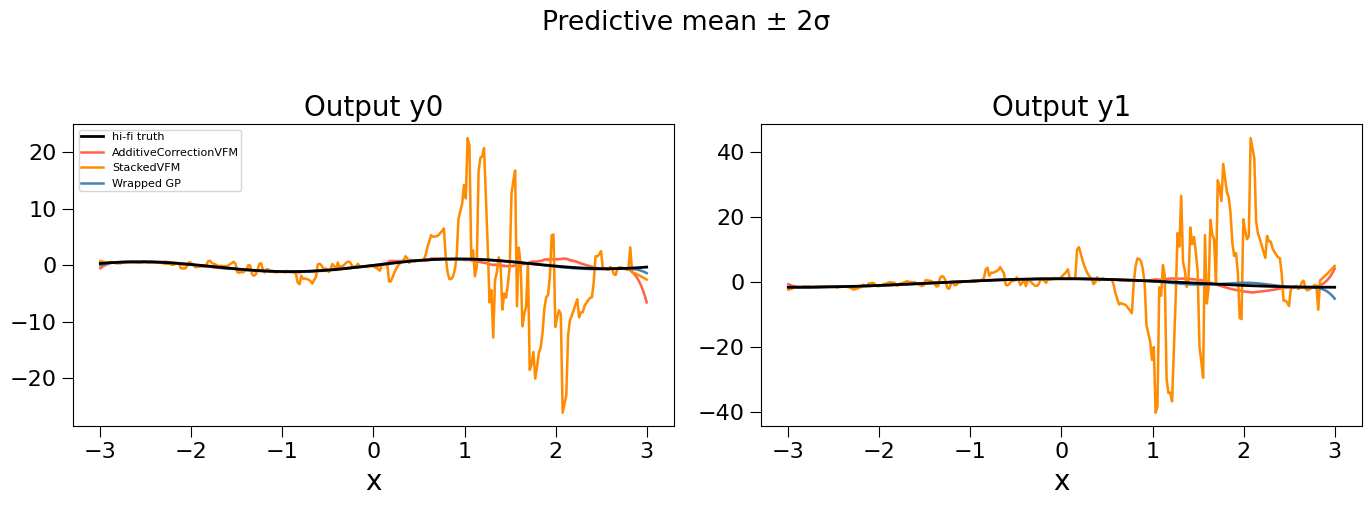

In [10]:
# Additive correction: combined uncertainty from lo and delta surrogates
y_pred_add, y_std_add = additive.predict(X_test, return_std=True)

# Stacked VFM: std from the top-level surrogate (GP here)
y_pred_stk, y_std_stk = stacked.predict(X_test, return_std=True)

# Wrapped GP: independent GP at the hi level
gp_wrapped = wrapped_models["Wrapped · GP"]
y_pred_gp, y_std_gp = gp_wrapped.predict(X_test, level="hi", return_std=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)

for j, ax in enumerate(axes):
    x = X_test[:, 0]
    ax.plot(x, Y_true[:, j], color="black", lw=2, label="hi-fi truth", zorder=5)

    for label, y_p, y_s, color in [
        ("AdditiveCorrectionVFM", y_pred_add, y_std_add, "tomato"),
        ("StackedVFM",            y_pred_stk, y_std_stk, "darkorange"),
        ("Wrapped GP",            y_pred_gp,  y_std_gp,  "steelblue"),
    ]:
        ax.plot(x, y_p[:, j], color=color, lw=1.8, label=label)
        ax.fill_between(x,
                         y_p[:, j] - 2 * y_s[:, j],
                         y_p[:, j] + 2 * y_s[:, j],
                         color=color, alpha=0.15)

    ax.set_title(f"Output y{j}")
    ax.set_xlabel("x")

axes[0].legend(fontsize=8)
fig.suptitle("Predictive mean ± 2σ", y=1.02)
fig.tight_layout()
plt.show()

## Summary

| Model | Information transfer | Uncertainty | Levels |
|---|---|---|---|
| `MultiFidelitySurrogate` | None — independent per level | Depends on inner surrogate | Any |
| `StackedVFMSurrogate` | Nonlinear (feature augmentation) | From top-level surrogate | ≥ 2 |
| `AdditiveCorrectionVFM` | Additive (f_lo + delta) | Quadrature combination | 2 only |

**Rule of thumb:**
- If you only have a few dozen hi-fi samples, prefer a native MF model.
- `AdditiveCorrectionVFM` is interpretable and fast; `StackedVFMSurrogate` is more flexible for nonlinear cross-fidelity relationships or more than two levels.